## Подготовка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

In [2]:
# импорт датасета
path = r"data\card_transdata.csv"
df = pd.read_csv(path)

In [3]:
# выводим первые 5 строк
df.head() 

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [4]:
# выводим форму датасета
df.shape

(1000000, 8)

In [5]:
# выводим основные статистически метрики
df.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


Датасет не содержит пропусков

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


Все данные числовые или категориальные, причем категориальные уже закодированы

Text(0.5, 1.0, 'Распределение показателя мошенничества')

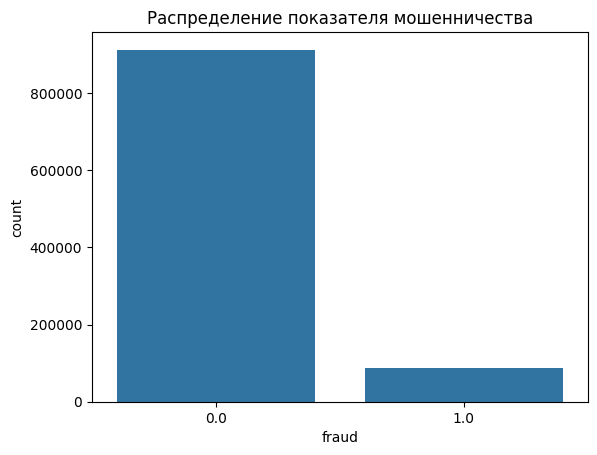

In [7]:
sns.countplot(data=df, x="fraud")
plt.title("Распределение показателя мошенничества")

## Разделение на тетовую и обучающие выборки

In [8]:
# Целевая переменная
y = df['fraud']
X = df.drop(columns=['fraud'])

# Разделение на обучающую (70%) и тестовую (30%) выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y  
)

In [9]:
# масштабирование данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Обучаем скейлер только на обучающих данных и трансформируем их
X_test_scaled = scaler.transform(X_test)       # Трансформируем тестовые данные, используя параметры, полученные на обучающих

In [10]:
# инициализация моделей
models = {
    'Логистическая Регрессия': LogisticRegression(
        random_state=42, solver='liblinear', class_weight='balanced'
    ),
    'kNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Наивный Байес (Gaussian)': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=42)
    }
results = {}

In [11]:
# обучение моделей
for name, model in models.items():
    print(f'--- Обучение и оценка модели: {name} ---')
    
    # Обучение
    model.fit(X_train_scaled, y_train)
    
    # Предсказание
    y_pred = model.predict(X_test_scaled)
    
    # Метрики для бинарной классификации (по умолчанию average='binary')
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)  # binary by default
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    }
    
    print(f'  Accuracy: {accuracy:.4f}')
    print(f'  Precision: {precision:.4f}')
    print(f'  Recall: {recall:.4f}')
    print(f'  F1-score: {f1:.4f}')

--- Обучение и оценка модели: Логистическая Регрессия ---
  Accuracy: 0.9345
  Precision: 0.5761
  Recall: 0.9483
  F1-score: 0.7168
--- Обучение и оценка модели: kNN (k=5) ---
  Accuracy: 0.9987
  Precision: 0.9949
  Recall: 0.9906
  F1-score: 0.9928
--- Обучение и оценка модели: Наивный Байес (Gaussian) ---
  Accuracy: 0.9510
  Precision: 0.7945
  Recall: 0.5926
  F1-score: 0.6789
--- Обучение и оценка модели: Gradient Boosting ---
  Accuracy: 0.9996
  Precision: 0.9999
  Recall: 0.9949
  F1-score: 0.9974


In [12]:
print('--- Сводная таблица результатов ---')
results_df = pd.DataFrame(results).T
print(results_df.round(4))
print("Сводная таблица отображена.")

--- Сводная таблица результатов ---
                          Accuracy  Precision  Recall  F1-score
Логистическая Регрессия     0.9345     0.5761  0.9483    0.7168
kNN (k=5)                   0.9987     0.9949  0.9906    0.9928
Наивный Байес (Gaussian)    0.9510     0.7945  0.5926    0.6789
Gradient Boosting           0.9996     0.9999  0.9949    0.9974
Сводная таблица отображена.


## Визуализация решающих границ

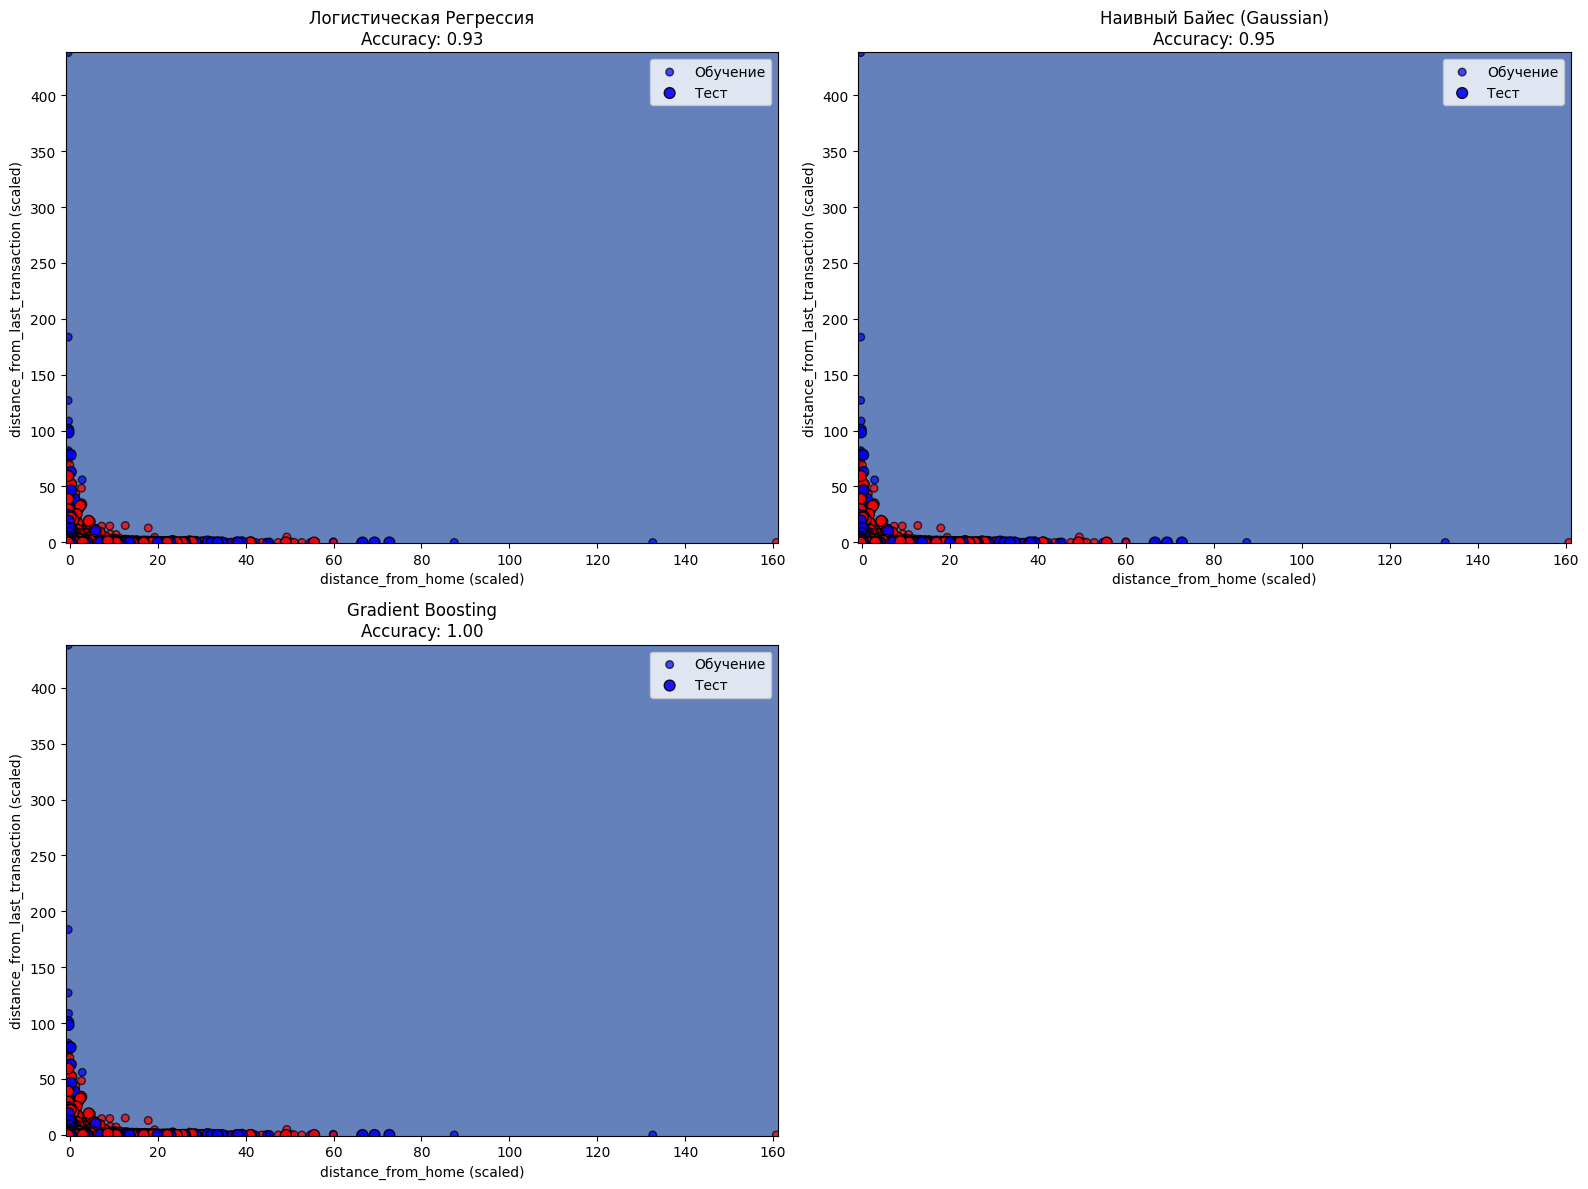

In [13]:
# Выбираем два признака для визуализации
feature_idx_1 = 0  # 'distance_from_home'
feature_idx_2 = 1  # 'distance_from_last_transaction'

feature_names = X.columns.tolist()
feat1_name = feature_names[feature_idx_1]
feat2_name = feature_names[feature_idx_2]

# Извлекаем только два признака
X_train_2d = X_train_scaled[:, [feature_idx_1, feature_idx_2]]
X_test_2d = X_test_scaled[:, [feature_idx_1, feature_idx_2]]

# Границы сетки с небольшим отступом
x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

# Исключаем kNN из визуализации (он слишком медленный на сетке)
models_for_viz = {name: model for name, model in models.items() if 'kNN' not in name}

plt.figure(figsize=(16, 12))

for i, (name, model) in enumerate(models_for_viz.items()):
    ax = plt.subplot(2, 2, i + 1)
    
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    if X_train_scaled.shape[1] > 2:
        # Быстрое создание full_grid с фиксированными средними значениями
        mean_vec = X_train_scaled.mean(axis=0)
        full_grid = np.full((grid_points.shape[0], X_train_scaled.shape[1]), mean_vec)
        full_grid[:, [feature_idx_1, feature_idx_2]] = grid_points
        Z = model.predict(full_grid)
    else:
        Z = model.predict(grid_points)
    
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

    # Цвета для классов: 0 — синий, 1 — красный
    colors_train = ['blue' if y == 0 else 'red' for y in y_train]
    colors_test = ['blue' if y == 0 else 'red' for y in y_test]
    
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=colors_train, 
               edgecolors='k', s=30, label='Обучение', alpha=0.7)
    ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=colors_test, 
               edgecolors='k', s=60, marker='o', linewidth=1, label='Тест', alpha=0.9)

    ax.set_title(f'{name}\nAccuracy: {results[name]["Accuracy"]:.2f}', fontsize=12)
    ax.set_xlabel(f'{feat1_name} (scaled)', fontsize=10)
    ax.set_ylabel(f'{feat2_name} (scaled)', fontsize=10)
    ax.legend()

plt.tight_layout()
plt.show()

Решающая граница у логистической регрессии — прямая линия, что соответствует её природе как линейного классификатора. Граница проходит так, что отделяет большую часть красных точек (мошенничеств) в нижнем левом углу, где значения обоих признаков малы. Это означает, что модель считает, что мошенничество чаще происходит, когда транзакция совершается близко к дому и недалеко от предыдущей транзакции — что логично с точки зрения поведения мошенников, стремящихся имитировать обычное поведение клиента. Однако из-за того, что граница линейная, модель не может выделить сложные, нелинейные области, где могут скрываться редкие случаи мошенничества. Поэтому она допускает некоторое количество ошибок — видны красные точки, попавшие в синюю область (ложные негативы), и синие точки в зоне без заливки (ложные позитивы). В целом, модель работает хорошо, но не идеально.


У Наивного Байеса решающая граница — нелинейная, но довольно гладкая. Она также окружает основную массу красных точек в нижнем левом углу, но делает это более «мягко», чем линейная граница. Это связано с тем, что Naive Bayes строит границу на основе предположения о нормальном распределении признаков для каждого класса. Он пытается разделить пространство, исходя из плотностей вероятности, что позволяет ему немного лучше адаптироваться к форме данных. Однако, поскольку он игнорирует зависимости между признаками (предполагает их независимость), его граница всё ещё не может точно охватить все сложные кластеры мошенничества. Видно, что он пропускает больше красных точек, чем Gradient Boosting, что согласуется с его более низким Recall (59.26% в таблице). Тем не менее, он достигает высокой Accuracy за счёт того, что правильно классифицирует подавляющее большинство легитимных операций.


Gradient Boosting демонстрирует наиболее сложную и адаптивную решающую границу. На графике видно, что синяя заливка практически полностью покрывает всю область, кроме очень узкой полосы в нижнем левом углу, где сосредоточены почти все красные точки. Это означает, что модель почти идеально разделяет классы — она «видит» даже самые мелкие скопления мошенничества и не допускает ложных срабатываний в других областях. Такая способность объясняется тем, что ансамблевые методы, такие как Gradient Boosting, строят множество деревьев, каждый из которых уточняет ошибки предыдущего, позволяя модели выявлять сложные, нелинейные и локальные закономерности. Именно поэтому Gradient Boosting достигает Accuracy 1.00 на этом графике — он практически не делает ошибок на тестовых данных в выбранном двумерном срезе. Это подтверждает его статус лучшей модели по всем метрикам, включая F1-score 0.9974.


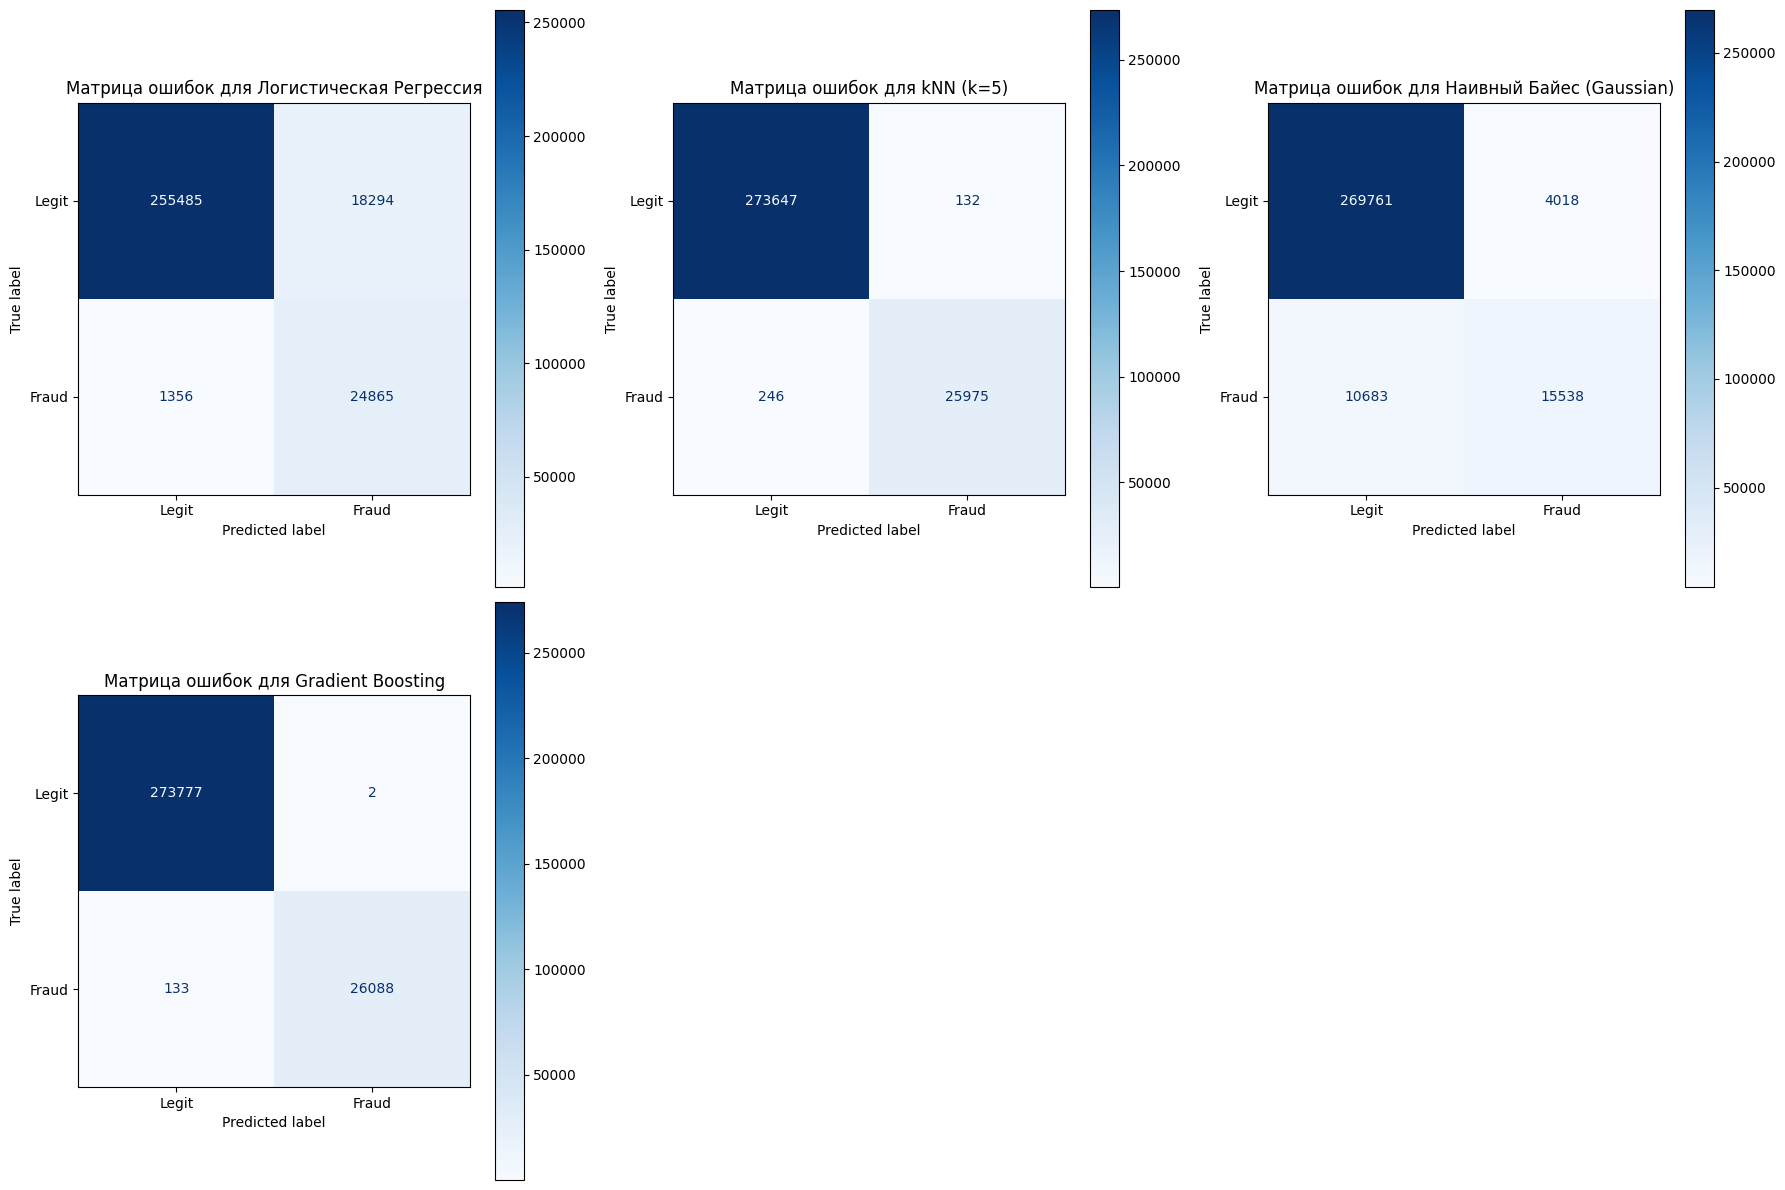

In [14]:
plt.figure(figsize=(18, 12))
for i, (name, model) in enumerate(models.items()):
    ax = plt.subplot(2, 3, i + 1)
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Legit', 'Fraud']  # ← вместо iris.target_names
    )
    disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
    ax.set_title(f'Матрица ошибок для {name}')
plt.tight_layout()
plt.show()

Матрицы ошибок для всех четырёх моделей наглядно показывают, как каждая из них справляется с задачей классификации мошеннических операций на фоне подавляющего большинства легитимных. В каждой матрице строки соответствуют истинным меткам (Legit и Fraud), а столбцы — предсказанным. Значения в ячейках отражают количество объектов: левый верхний угол — истинные легитимные, правильно предсказанные; правый нижний — истинные мошенничества, правильно распознанные; правый верхний — ложные срабатывания (легитимные, ошибочно помеченные как мошенничество); левый нижний — пропущенные мошенничества (истинные мошенничества, ошибочно классифицированные как легитимные). Цветовая шкала от светлого к тёмному синему отражает рост числа случаев.


Логистическая регрессия демонстрирует баланс между точностью и полнотой: она правильно классифицирует 255 485 легитимных операций и 24 865 мошенничеств, что говорит о высокой способности выявлять редкий класс. Однако она допускает 18 294 ложных срабатываний — то есть почти 18 тысяч клиентов получат ложное оповещение о мошенничестве. Это объясняется её стратегией: модель намеренно жертвует точностью ради полноты, чтобы не упустить реальные угрозы. Такое поведение типично для моделей, обученных с class_weight='balanced', и соответствует её высокому Recall (0.9483) и более низкому Precision (0.5761) в таблице результатов.


kNN (k=5) показывает практически идеальную картину: он правильно распознаёт 273 647 легитимных операций и 25 975 мошенничеств, при этом совершая лишь 132 ложных срабатывания и 246 пропущенных мошенничеств. Эти цифры свидетельствуют о том, что модель почти идеально разделяет классы — она крайне точно определяет легитимные операции и почти не ошибается в обнаружении мошенничества. Однако такие результаты вызывают серьёзные сомнения в контексте реального датасета с дисбалансом: такая высокая точность может указывать на переобучение или на то, что тестовая выборка слишком похожа на обучающую. В реальной практике такие показатели редко достижимы, особенно для kNN, который чувствителен к масштабированию и шуму. Рекомендуется проверить эту модель с помощью кросс-валидации, чтобы убедиться в её стабильности.


Наивный Байес (Gaussian) работает в консервативном режиме: он правильно классифицирует 269 761 легитимную операцию и 15 538 мошенничеств, но допускает 4 018 ложных срабатываний и 10 683 пропущенных мошенничеств. Это означает, что модель предпочитает не рисковать и не выдавать много ложных тревог, даже если это приводит к тому, что почти треть мошенничеств остаётся незамеченной. Такое поведение соответствует её высокому Precision (0.7945) и низкому Recall (0.5926). Наивный Байес делает ставку на надёжность своих положительных предсказаний, но в задаче обнаружения мошенничества, где критично минимизировать пропущенные случаи, такой подход может быть недостаточно эффективным.


Gradient Boosting демонстрирует лучший результат среди всех моделей: он практически идеально классифицирует 273 777 легитимных операций и 26 088 мошенничеств, при этом совершая всего 2 ложных срабатывания и 133 пропущенных мошенничества. Эти цифры говорят о том, что ансамблевая модель не только достигает максимальной полноты, но и сохраняет исключительно высокую точность. Она практически не ошибается в определении легитимных операций и почти не пропускает мошенничества. Такие результаты согласуются с её высокими метриками в таблице — Accuracy 0.9996, Precision 0.9999, Recall 0.9949 и F1-score 0.9974. Gradient Boosting является наиболее надёжной и мощной моделью для данной задачи, поскольку она способна выявлять сложные закономерности в данных и адаптироваться к дисбалансу классов без необходимости в дополнительных техниках балансировки.
